# 2022 国赛 C 题｜第 1 课：读题与数据体检

目标：
1. 读入三个表单；
2. 区分“文物”和“采样点”；
3. 合并基本信息与化学成分；
4. 检查成分总和是否在 85%～105%；
5. 做第一张列联统计图。


## 0. 文件准备

把本 Notebook 和 `附件.xlsx` 放在同一个文件夹中，然后从上到下运行。


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 中文显示设置；某些电脑没有这些字体时，图中文字可能仍无法显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False


## 1. 读入三个表单


In [2]:
file_path = '附件.xlsx'

info = pd.read_excel(file_path, sheet_name='表单1', dtype={'文物编号': str})
chem = pd.read_excel(file_path, sheet_name='表单2', dtype={'文物采样点': str})
unknown = pd.read_excel(file_path, sheet_name='表单3', dtype={'文物编号': str})

# 防止 01 被读成 1
info['文物编号'] = info['文物编号'].str.strip().str.zfill(2)
chem['文物采样点'] = chem['文物采样点'].str.strip()

print('表单1形状：', info.shape)
print('表单2形状：', chem.shape)
print('表单3形状：', unknown.shape)

display(info.head())
display(chem.head())
display(unknown.head())


表单1形状： (58, 5)
表单2形状： (69, 15)
表单3形状： (8, 16)


,文物编号,纹饰,类型,颜色,表面风化
0,01,C,高钾,蓝绿,无风化
1,02,A,铅钡,浅蓝,风化
2,03,A,高钾,蓝绿,无风化
3,04,A,高钾,蓝绿,无风化
4,05,A,高钾,蓝绿,无风化


,文物采样点,二氧化硅(SiO2),氧化钠(Na2O),氧化钾(K2O),氧化钙(CaO),氧化镁(MgO),氧化铝(Al2O3),氧化铁(Fe2O3),氧化铜(CuO),氧化铅(PbO),氧化钡(BaO),五氧化二磷(P2O5),氧化锶(SrO),氧化锡(SnO2),二氧化硫(SO2)
0,01,69.33,NaN,9.99,6.32,0.87,3.93,1.74,3.87,NaN,NaN,1.17,NaN,NaN,0.39
1,02,36.28,NaN,1.05,2.34,1.18,5.73,1.86,0.26,47.43,NaN,3.57,0.19,NaN,NaN
2,03部位1,87.05,NaN,5.19,2.01,NaN,4.06,NaN,0.78,0.25,NaN,0.66,NaN,NaN,NaN
3,03部位2,61.71,NaN,12.37,5.87,1.11,5.50,2.16,5.09,1.41,2.86,0.70,0.10,NaN,NaN
4,04,65.88,NaN,9.67,7.12,1.56,6.44,2.06,2.18,NaN,NaN,0.79,NaN,NaN,0.36


,文物编号,表面风化,二氧化硅(SiO2),氧化钠(Na2O),氧化钾(K2O),氧化钙(CaO),氧化镁(MgO),氧化铝(Al2O3),氧化铁(Fe2O3),氧化铜(CuO),氧化铅(PbO),氧化钡(BaO),五氧化二磷(P2O5),氧化锶(SrO),氧化锡(SnO2),二氧化硫(SO2)
0,A1,无风化,78.45,NaN,NaN,6.08,1.86,7.23,2.15,2.11,NaN,NaN,1.06,0.03,NaN,0.51
1,A2,风化,37.75,NaN,NaN,7.63,NaN,2.33,NaN,NaN,34.30,NaN,14.27,NaN,NaN,NaN
2,A3,无风化,31.95,NaN,1.36,7.19,0.81,2.93,7.06,0.21,39.58,4.69,2.68,0.52,NaN,NaN
3,A4,无风化,35.47,NaN,0.79,2.89,1.05,7.07,6.45,0.96,24.28,8.31,8.45,0.28,NaN,NaN
4,A5,风化,64.29,1.2,0.37,1.64,2.34,12.75,0.81,0.94,12.23,2.16,0.19,0.21,0.49,NaN


你应当看到：
- 表单 1：58 行、5 列；
- 表单 2：69 行、15 列；
- 表单 3：8 行、16 列。

58 件文物却有 69 个采样点，是因为有些文物存在“部位1、部位2、未风化点、严重风化点”等多个检测点。


## 2. 查看基本信息和缺失值


In [3]:
print('基本信息缺失值：')
display(info.isna().sum().to_frame('缺失数量'))

for col in ['纹饰', '类型', '颜色', '表面风化']:
    print(f'\n{col}：')
    display(info[col].value_counts(dropna=False).to_frame('数量'))


基本信息缺失值：


,缺失数量
文物编号,0
纹饰,0
类型,0
颜色,4
表面风化,0



纹饰：


,数量
纹饰,
C,30
A,22
B,6



类型：


,数量
类型,
铅钡,40
高钾,18



颜色：


,数量
颜色,
浅蓝,20
蓝绿,15
深绿,7
紫,4
NaN,4
浅绿,3
深蓝,2
黑,2
绿,1



表面风化：


,数量
表面风化,
风化,34
无风化,24


注意：颜色有少量缺失，但类型、纹饰、表面风化没有缺失。不要看到缺失值就立刻删行，要先判断它是否影响当前问题。


## 3. 从采样点名称中提取文物编号，再合并表单


In [4]:
# 例如：'03部位1'、'26严重风化点' 的前两位都是文物编号
chem['文物编号'] = chem['文物采样点'].str.extract(r'^(\d{2})')

data = chem.merge(
    info,
    on='文物编号',
    how='left',
    validate='many_to_one'  # 多个采样点可以对应同一件文物
)

print('合并后形状：', data.shape)
print('没有匹配到基本信息的采样点数量：', data['类型'].isna().sum())
display(data[['文物采样点', '文物编号', '纹饰', '类型', '颜色', '表面风化']].head(12))


合并后形状： (69, 20)
没有匹配到基本信息的采样点数量： 0


,文物采样点,文物编号,纹饰,类型,颜色,表面风化
0,01,01,C,高钾,蓝绿,无风化
1,02,02,A,铅钡,浅蓝,风化
2,03部位1,03,A,高钾,蓝绿,无风化
3,03部位2,03,A,高钾,蓝绿,无风化
4,04,04,A,高钾,蓝绿,无风化
5,05,05,A,高钾,蓝绿,无风化
6,06部位1,06,A,高钾,蓝绿,无风化
7,06部位2,06,A,高钾,蓝绿,无风化
8,07,07,B,高钾,蓝绿,风化
9,08,08,C,铅钡,紫,风化


## 4. 区分“整件文物的表面风化”和“采样点的风化状态”


In [5]:
# 默认继承整件文物的表面风化属性
data['采样点风化状态'] = data['表面风化']

# 题目明确标出的特殊采样点要单独处理
data.loc[data['文物采样点'].str.contains('未风化点'), '采样点风化状态'] = '无风化'
data.loc[data['文物采样点'].str.contains('严重风化点'), '采样点风化状态'] = '严重风化'

# 后续若只比较“风化/无风化”，可再做一个二分类变量
data['采样点是否风化'] = np.where(
    data['采样点风化状态'].eq('无风化'), '无风化', '风化'
)

display(
    data.loc[
        data['文物采样点'].str.contains('未风化点|严重风化点'),
        ['文物采样点', '表面风化', '采样点风化状态', '采样点是否风化']
    ]
)


,文物采样点,表面风化,采样点风化状态,采样点是否风化
10,08严重风化点,风化,严重风化,风化
25,23未风化点,风化,无风化,无风化
27,25未风化点,风化,无风化,无风化
29,26严重风化点,风化,严重风化,风化
31,28未风化点,风化,无风化,无风化
32,29未风化点,风化,无风化,无风化
46,42未风化点1,风化,无风化,无风化
47,42未风化点2,风化,无风化,无风化
50,44未风化点,风化,无风化,无风化
56,49未风化点,风化,无风化,无风化


## 5. 检查化学成分总和是否有效


In [6]:
# 表单2中，第2列到第15列都是化学成分
component_cols = chem.columns[1:15].tolist()

# 空白表示未检测到该成分。做总和检查时按 0 处理，但先不要覆盖原始数据
data['成分总和'] = data[component_cols].fillna(0).sum(axis=1)
data['是否有效'] = data['成分总和'].between(85, 105, inclusive='both')

print(data['是否有效'].value_counts())
display(
    data.loc[~data['是否有效'], ['文物采样点', '成分总和']]
        .sort_values('成分总和')
)


是否有效
True     67
False     2
Name: count, dtype: int64


,文物采样点,成分总和
19,17,71.89
17,15,79.47


正确结果应为：
- 有效采样点 67 个；
- 无效采样点 2 个；
- 无效采样点是 15 和 17，它们的成分总和分别约为 79.47 和 71.89。

后续化学成分建模通常先使用 `data_valid = data[data['是否有效']].copy()`。


In [7]:
data_valid = data[data['是否有效']].copy()
print('有效数据形状：', data_valid.shape)


有效数据形状： (67, 24)


## 6. 第一张统计表和第一张图


表面风化,无风化,风化,All
类型,,,
铅钡,12,28,40
高钾,12,6,18
All,24,34,58


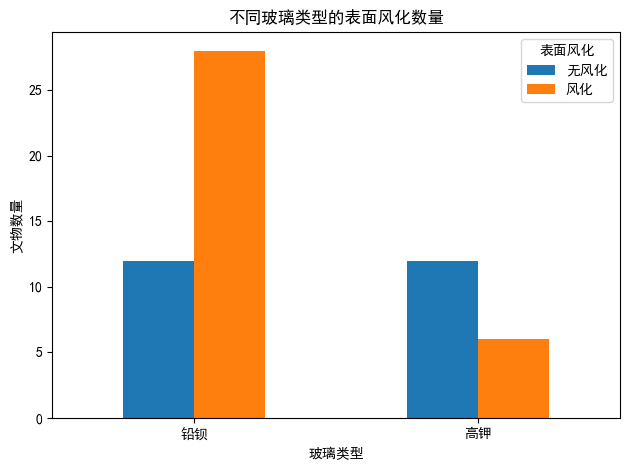

In [8]:
# 问题1的第一部分研究的是“文物层面”的表面风化关系，因此先使用表单1
type_weather = pd.crosstab(info['类型'], info['表面风化'], margins=True)
display(type_weather)

pd.crosstab(info['类型'], info['表面风化']).plot(kind='bar')
plt.title('不同玻璃类型的表面风化数量')
plt.xlabel('玻璃类型')
plt.ylabel('文物数量')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
